# Metro Interstate Traffic Volume — Model Training

**Notebook 2 of 2**

This notebook trains, evaluates, and selects the final production models using the cleaned dataset produced
by `01_EDA_and_Preprocessing.ipynb`.

**Part A — Regression:** predict the exact `traffic_volume`.

**Part B — Classification:** predict `traffic_level` (Low / Moderate / High).

Only the best-performing model from each part is persisted to `models/` for deployment in `app.py`.


## 1. Imports

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
)
from xgboost import XGBRegressor, XGBClassifier

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42


## 2. Load Cleaned Dataset

In [2]:
df = pd.read_csv("data/traffic_processed.csv")
print(f"Shape: {df.shape}")
df.head()


Shape: (40575, 28)


,temp,rain_1h,snow_1h,clouds_all,date_time,traffic_volume,is_holiday,month,day,hour,...,weather_Drizzle,weather_Fog,weather_Haze,weather_Mist,weather_Rain,weather_Smoke,weather_Snow,weather_Squall,weather_Thunderstorm,traffic_level_encoded
0,288.28,0.0,0.0,40,2012-10-02 09:00:00,5545,0,10,2,9,...,False,False,False,False,False,False,False,False,False,2
1,289.36,0.0,0.0,75,2012-10-02 10:00:00,4516,0,10,2,10,...,False,False,False,False,False,False,False,False,False,1
2,289.58,0.0,0.0,90,2012-10-02 11:00:00,4767,0,10,2,11,...,False,False,False,False,False,False,False,False,False,2
3,290.13,0.0,0.0,90,2012-10-02 12:00:00,5026,0,10,2,12,...,False,False,False,False,False,False,False,False,False,2
4,291.14,0.0,0.0,75,2012-10-02 13:00:00,4918,0,10,2,13,...,False,False,False,False,False,False,False,False,False,2


### 2.1 Define feature sets

`traffic_volume`, `traffic_level`, and `traffic_level_encoded` are mutually derived from one another, so each
task must exclude the other task's target(s) to avoid data leakage. `date_time` is dropped since all of its
signal has already been captured by the engineered datetime features.


In [3]:
LEAK_COLUMNS = ["date_time", "traffic_volume", "traffic_level", "traffic_level_encoded"]

feature_columns = [c for c in df.columns if c not in LEAK_COLUMNS]

if "year" in feature_columns:
    feature_columns.remove("year")
    
print(f"Number of features: {len(feature_columns)}")
feature_columns


Number of features: 24


['temp',
 'rain_1h',
 'snow_1h',
 'clouds_all',
 'is_holiday',
 'month',
 'day',
 'hour',
 'day_of_week',
 'is_weekend',
 'hour_sin',
 'hour_cos',
 'month_sin',
 'month_cos',
 'weather_Clouds',
 'weather_Drizzle',
 'weather_Fog',
 'weather_Haze',
 'weather_Mist',
 'weather_Rain',
 'weather_Smoke',
 'weather_Snow',
 'weather_Squall',
 'weather_Thunderstorm']

---
## PART A — Regression: Predicting `traffic_volume`
---

### 3. Train / Test Split

In [4]:
X = df[feature_columns]
y_reg = df["traffic_volume"]

X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (32460, 24), Test shape: (8115, 24)


### 4. Model 1 — Linear Regression (Baseline)

In [5]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_reg_train)

lr_preds = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_reg_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_reg_test, lr_preds))
lr_r2 = r2_score(y_reg_test, lr_preds)

print(f"Linear Regression -> MAE: {lr_mae:.2f} | RMSE: {lr_rmse:.2f} | R2: {lr_r2:.4f}")


Linear Regression -> MAE: 817.39 | RMSE: 1052.30 | R2: 0.7173


### 5. Model 2 — XGBoost Regressor

In [6]:
xgb_reg_model = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_reg_model.fit(X_train, y_reg_train)

xgb_reg_preds = xgb_reg_model.predict(X_test)

xgb_reg_mae = mean_absolute_error(y_reg_test, xgb_reg_preds)
xgb_reg_rmse = np.sqrt(mean_squared_error(y_reg_test, xgb_reg_preds))
xgb_reg_r2 = r2_score(y_reg_test, xgb_reg_preds)

print(f"XGBoost Regressor -> MAE: {xgb_reg_mae:.2f} | RMSE: {xgb_reg_rmse:.2f} | R2: {xgb_reg_r2:.4f}")


XGBoost Regressor -> MAE: 219.73 | RMSE: 356.28 | R2: 0.9676


### 6. Regression — Actual vs. Predicted

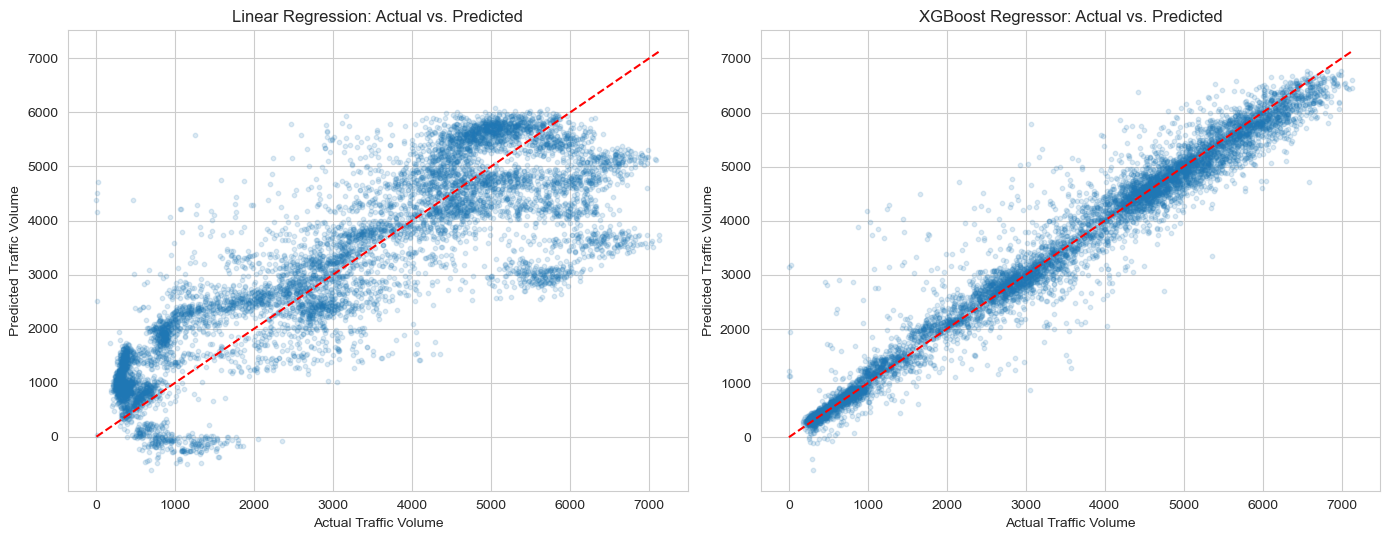

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, preds, title in zip(
    axes, [lr_preds, xgb_reg_preds], ["Linear Regression", "XGBoost Regressor"]
):
    ax.scatter(y_reg_test, preds, alpha=0.15, s=10)
    ax.plot(
        [y_reg_test.min(), y_reg_test.max()],
        [y_reg_test.min(), y_reg_test.max()],
        color="red", linestyle="--", linewidth=1.5,
    )
    ax.set_title(f"{title}: Actual vs. Predicted")
    ax.set_xlabel("Actual Traffic Volume")
    ax.set_ylabel("Predicted Traffic Volume")

plt.tight_layout()
plt.show()


### 7. Regression Feature Importance (XGBoost)

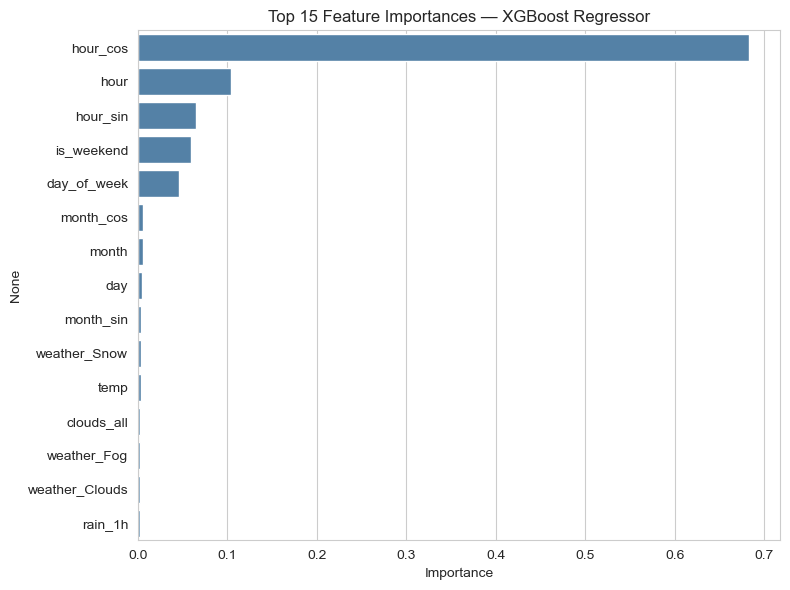

In [8]:
importances = pd.Series(xgb_reg_model.feature_importances_, index=feature_columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, color="steelblue")
plt.title("Top 15 Feature Importances — XGBoost Regressor")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


### 8. Regression Model Comparison

In [9]:
regression_results = pd.DataFrame({
    "Model": ["Linear Regression", "XGBoost Regressor"],
    "MAE": [lr_mae, xgb_reg_mae],
    "RMSE": [lr_rmse, xgb_reg_rmse],
    "R2": [lr_r2, xgb_reg_r2],
}).round(4)

regression_results


,Model,MAE,RMSE,R2
0,Linear Regression,817.3870,1052.2953,0.7173
1,XGBoost Regressor,219.7308,356.2790,0.9676


In [10]:
best_regressor_name = regression_results.loc[regression_results["R2"].idxmax(), "Model"]
best_regressor = xgb_reg_model if best_regressor_name == "XGBoost Regressor" else lr_model

print(f"Selected Regression Model: {best_regressor_name}")
print(
    "Reason: it achieves the highest R2 and lowest MAE/RMSE of the two candidates on the held-out test set, "
    "and as a gradient-boosted ensemble it captures non-linear interactions between time and weather features "
    "that a linear model cannot."
)


Selected Regression Model: XGBoost Regressor
Reason: it achieves the highest R2 and lowest MAE/RMSE of the two candidates on the held-out test set, and as a gradient-boosted ensemble it captures non-linear interactions between time and weather features that a linear model cannot.


### 9. Save Best Regression Model

In [11]:
import os
os.makedirs("../models", exist_ok=True)

joblib.dump(best_regressor, "models/xgb_regressor.pkl")
print("Saved best regression model to models/xgb_regressor.pkl")


Saved best regression model to models/xgb_regressor.pkl


---
## PART B — Classification: Predicting `traffic_level`
---

### 10. Train / Test Split

`traffic_level` was already derived in Notebook 1 using quantile-based thresholds on `traffic_volume`
(Low / Moderate / High, roughly balanced). We reuse the same feature set as Part A.


In [12]:
y_clf = df["traffic_level_encoded"]
class_names = ["Low", "Moderate", "High"]

X_train_c, X_test_c, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

print(f"Train shape: {X_train_c.shape}, Test shape: {X_test_c.shape}")
y_clf_train.value_counts(normalize=True).round(3)


Train shape: (32460, 24), Test shape: (8115, 24)


traffic_level_encoded
0    0.333
1    0.333
2    0.333
Name: proportion, dtype: float64

### 11. Model 1 — Decision Tree

In [13]:
dt_model = DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE)
dt_model.fit(X_train_c, y_clf_train)

dt_preds = dt_model.predict(X_test_c)

dt_acc = accuracy_score(y_clf_test, dt_preds)
dt_prec = precision_score(y_clf_test, dt_preds, average="weighted")
dt_rec = recall_score(y_clf_test, dt_preds, average="weighted")
dt_f1 = f1_score(y_clf_test, dt_preds, average="weighted")

print(f"Decision Tree -> Accuracy: {dt_acc:.4f} | Precision: {dt_prec:.4f} | Recall: {dt_rec:.4f} | F1: {dt_f1:.4f}")


Decision Tree -> Accuracy: 0.8951 | Precision: 0.8952 | Recall: 0.8951 | F1: 0.8950


### 12. Model 2 — Random Forest

In [14]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_model.fit(X_train_c, y_clf_train)

rf_preds = rf_model.predict(X_test_c)

rf_acc = accuracy_score(y_clf_test, rf_preds)
rf_prec = precision_score(y_clf_test, rf_preds, average="weighted")
rf_rec = recall_score(y_clf_test, rf_preds, average="weighted")
rf_f1 = f1_score(y_clf_test, rf_preds, average="weighted")

print(f"Random Forest -> Accuracy: {rf_acc:.4f} | Precision: {rf_prec:.4f} | Recall: {rf_rec:.4f} | F1: {rf_f1:.4f}")


Random Forest -> Accuracy: 0.9052 | Precision: 0.9057 | Recall: 0.9052 | F1: 0.9050


### 13. Model 3 — XGBoost Classifier

In [15]:
xgb_clf_model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric="mlogloss",
)
xgb_clf_model.fit(X_train_c, y_clf_train)

xgb_clf_preds = xgb_clf_model.predict(X_test_c)

xgb_clf_acc = accuracy_score(y_clf_test, xgb_clf_preds)
xgb_clf_prec = precision_score(y_clf_test, xgb_clf_preds, average="weighted")
xgb_clf_rec = recall_score(y_clf_test, xgb_clf_preds, average="weighted")
xgb_clf_f1 = f1_score(y_clf_test, xgb_clf_preds, average="weighted")

print(
    f"XGBoost Classifier -> Accuracy: {xgb_clf_acc:.4f} | Precision: {xgb_clf_prec:.4f} "
    f"| Recall: {xgb_clf_rec:.4f} | F1: {xgb_clf_f1:.4f}"
)


XGBoost Classifier -> Accuracy: 0.9145 | Precision: 0.9145 | Recall: 0.9145 | F1: 0.9143


### 14. Confusion Matrices

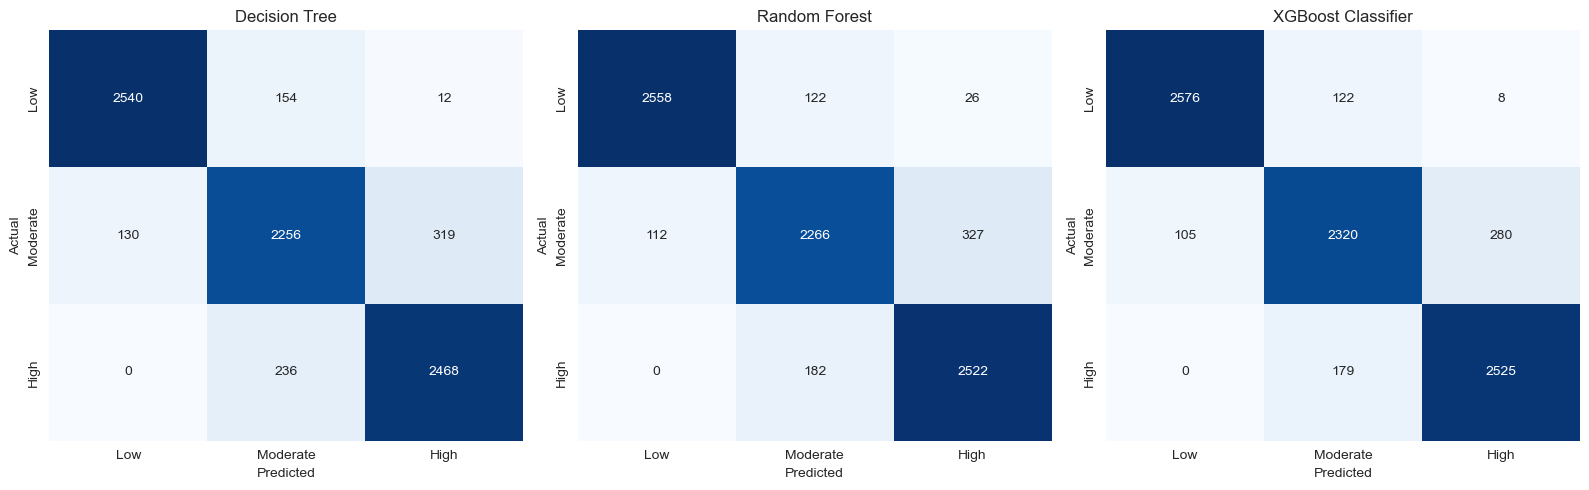

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, preds, title in zip(
    axes,
    [dt_preds, rf_preds, xgb_clf_preds],
    ["Decision Tree", "Random Forest", "XGBoost Classifier"],
):
    cm = confusion_matrix(y_clf_test, preds)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


### 15. Classification Feature Importance (Best Tree Ensemble)

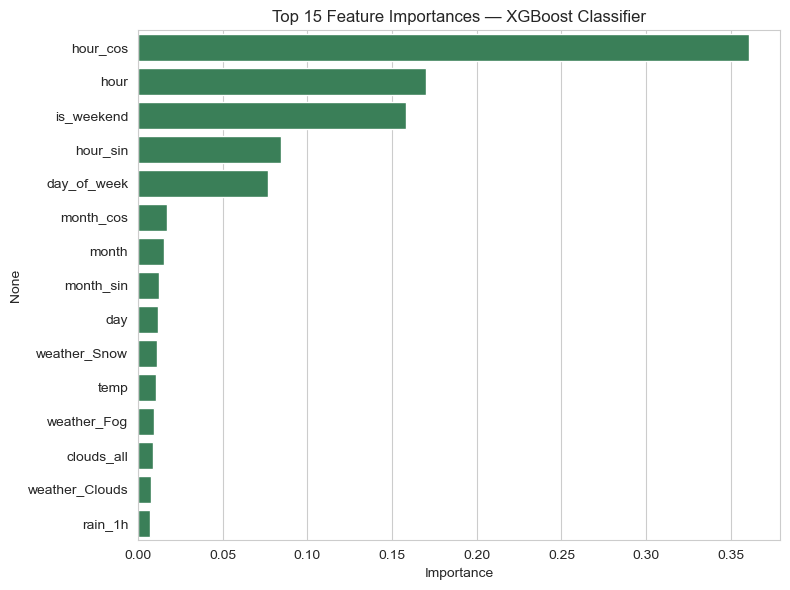

In [17]:
clf_importances = pd.Series(xgb_clf_model.feature_importances_, index=feature_columns)
clf_importances = clf_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=clf_importances.values, y=clf_importances.index, color="seagreen")
plt.title("Top 15 Feature Importances — XGBoost Classifier")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


### 16. Classification Model Comparison

In [18]:
classification_results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "XGBoost Classifier"],
    "Accuracy": [dt_acc, rf_acc, xgb_clf_acc],
    "Precision": [dt_prec, rf_prec, xgb_clf_prec],
    "Recall": [dt_rec, rf_rec, xgb_clf_rec],
    "F1": [dt_f1, rf_f1, xgb_clf_f1],
}).round(4)

classification_results


,Model,Accuracy,Precision,Recall,F1
0,Decision Tree,0.8951,0.8952,0.8951,0.8950
1,Random Forest,0.9052,0.9057,0.9052,0.9050
2,XGBoost Classifier,0.9145,0.9145,0.9145,0.9143


In [19]:
best_classifier_name = classification_results.loc[classification_results["F1"].idxmax(), "Model"]

classifier_lookup = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "XGBoost Classifier": xgb_clf_model,
}
best_classifier = classifier_lookup[best_classifier_name]

print(f"Selected Classification Model: {best_classifier_name}")
print(
    "Reason: it achieves the highest weighted F1 score (balancing precision and recall across all three "
    "traffic-level classes) on the held-out test set among the three candidates evaluated."
)


Selected Classification Model: XGBoost Classifier
Reason: it achieves the highest weighted F1 score (balancing precision and recall across all three traffic-level classes) on the held-out test set among the three candidates evaluated.


### 17. Save Best Classification Model

In [20]:
joblib.dump(best_classifier, "models/xgb_classifier.pkl")
print("Saved best classification model to models/xgb_classifier.pkl")


Saved best classification model to models/xgb_classifier.pkl


---
## 18. Final Summary
---

### Regression

In [21]:
regression_results


,Model,MAE,RMSE,R2
0,Linear Regression,817.3870,1052.2953,0.7173
1,XGBoost Regressor,219.7308,356.2790,0.9676


### Classification

In [22]:
classification_results


,Model,Accuracy,Precision,Recall,F1
0,Decision Tree,0.8951,0.8952,0.8951,0.8950
1,Random Forest,0.9052,0.9057,0.9052,0.9050
2,XGBoost Classifier,0.9145,0.9145,0.9145,0.9143


### Final Selected Models

In [23]:
from IPython.display import Markdown, display

summary_md = f"""
| Task | Selected Model | Saved Path |
|---|---|---|
| Regression | **{best_regressor_name}** | `models/xgb_regressor.pkl` |
| Classification | **{best_classifier_name}** | `models/xgb_classifier.pkl` |
"""

display(Markdown(summary_md))

print(
    "Both files are loaded directly by app.py for the Streamlit deployment. "
    "No other model artifacts are persisted, keeping the deployed application lightweight "
    "and unambiguous about which models are in production."
)



| Task | Selected Model | Saved Path |
|---|---|---|
| Regression | **XGBoost Regressor** | `models/xgb_regressor.pkl` |
| Classification | **XGBoost Classifier** | `models/xgb_classifier.pkl` |


Both files are loaded directly by app.py for the Streamlit deployment. No other model artifacts are persisted, keeping the deployed application lightweight and unambiguous about which models are in production.
